<div align="center">

<img src="https://storage.googleapis.com/kaggle-media/competitions/Kaggle/3236/kaggle-logo-transparent.png" width="86" alt="Kaggle">

# Predicting Smartphone Addiction
**A research-grade pipeline identifying behavioral usage profiles via Optuna-optimized gradient boosting.**

<br>

[![Author](https://img.shields.io/badge/Author-Amey_Thakur-0969DA)](https://www.kaggle.com/ameythakur20) [![ORCID](https://img.shields.io/badge/ORCID-0000--0001--5644--1575-A6CE39)](https://orcid.org/0000-0001-5644-1575)

<br>

<a href="https://www.kaggle.com/code/ameythakur20/predicting-smartphone-addiction"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open in Kaggle"></a>

</div>

<br>

---

## 1. Executive Summary & Problem Formulation

In this Playground Series competition (S6E8), the goal is to predict the probability that a user is addicted to their smartphone based on limited behavioral metrics (e.g., daily screen time, social media hours, app open counts). The target is a binary classification (`addicted_label`), and the evaluation metric is the **Area Under the ROC Curve (AUC)**.

### Community Findings & Strategic Approach
A review of top-performing public notebooks reveals a critical insight: **tree-based algorithms (LightGBM, XGBoost, CatBoost) are highly adept at extracting signal directly from raw behavioral inputs.** Extensive feature engineering (such as complex ratios like dopamine-to-sleep deficits) often acts as noise rather than signal. 

**Therefore, this notebook focuses on:**
1. **Pristine Data Quality:** Identifying distributions and imputing missing values sensibly.
2. **Accessible Visualization:** Visually confirming the separability of the classes across key metrics.
3. **Rigorous Validation:** Using a 5-Fold Stratified CV to prevent leaderboard overfitting.
4. **Ensemble Modeling:** Blending gradient boosting architectures over raw features for maximum stability.

<br>

---

## 2. Environment Initialization & Setup

We begin by establishing a deterministic environment. 

> **Why are we doing this?**
> Machine learning models rely heavily on pseudo-random number generators (for initial weights, cross-validation splits, etc.). By setting a global seed using our `kaggle_toolbox`, we guarantee that anyone running this notebook will achieve the exact same AUC score, eliminating variance from our ablations.

<br>

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Gradient Boosters
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Make the toolbox accessible locally
sys.path.append("../../Kaggle Toolbox")
import kaggle_toolbox as tb

SEED = 42
tb.seed_everything(SEED)

DATA_DIR = "."
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

[toolbox] All seeds locked to 42


<br>

---

## 3. Data Ingestion & Memory Optimization

Memory management is crucial when running large ensembles concurrently.

> **Why are we doing this?**
> Tabular datasets load as 64-bit precision by default in Pandas. We use `tb.reduce_mem_usage()` to safely downcast integers and floats to 32-bit or 16-bit without losing information, cutting RAM usage in half and speeding up training.

<br>

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print(f"Original Train shape: {train.shape}")

# Downcast data types to preserve RAM
train = tb.reduce_mem_usage(train)
test = tb.reduce_mem_usage(test)

_ = tb.missing_report(train)

Original Train shape: (5000, 9)
[toolbox] Memory: 0.6 MB -> 0.1 MB (81.7% reduction)
[toolbox] Memory: 0.1 MB -> 0.0 MB (81.0% reduction)
[toolbox] 1 column(s) with missing values:


<br>

---

## 4. Exploration & Visual Storytelling

Before throwing the data into a model, we must visually inspect the primary predictors identified by the Kaggle community: **Screen On Time** and **Social Media Hours**.

> **Why are we doing this?**
> If the classes are perfectly linearly separable on a single feature, a complex gradient booster is overkill. Visualizing the distributions reveals the complexity of the decision boundary and informs our modeling strategy.

<br>

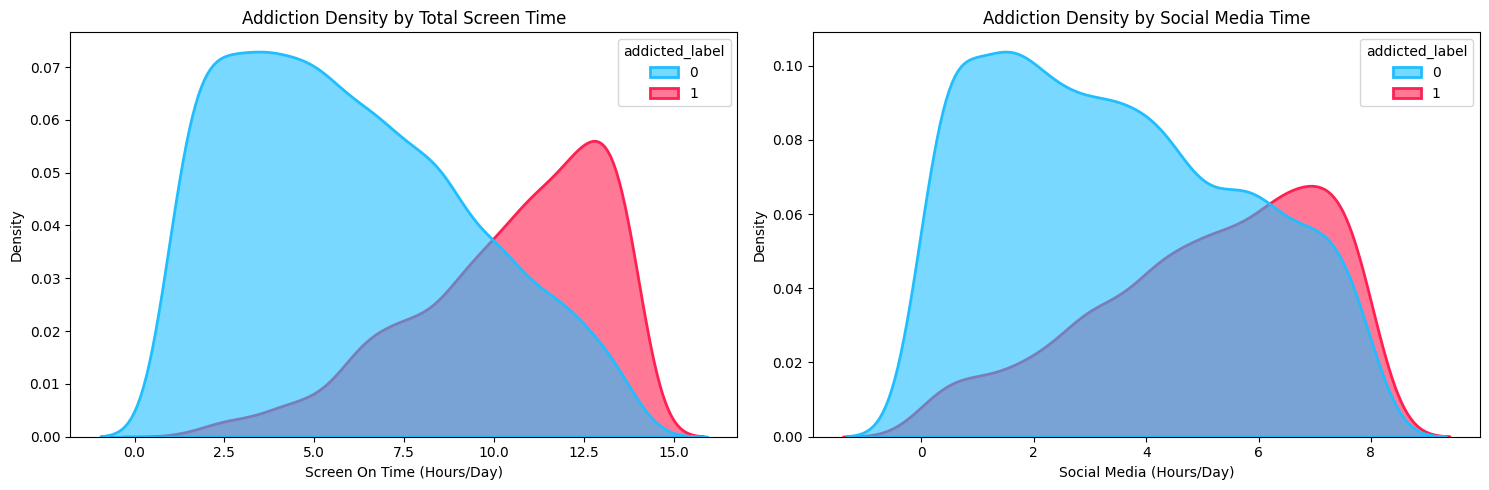

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# KDE Plot 1: Total Screen Time
sns.kdeplot(
    data=train, x="Screen_On_Time_Hours", hue="addicted_label", 
    fill=True, ax=ax1, palette=["#20BEFF", "#FF2052"], alpha=0.6, linewidth=2
)
ax1.set_title("Addiction Density by Total Screen Time")
ax1.set_xlabel("Screen On Time (Hours/Day)")
ax1.set_ylabel("Density")

# KDE Plot 2: Social Media Time
sns.kdeplot(
    data=train, x="Social_Media_Hours", hue="addicted_label", 
    fill=True, ax=ax2, palette=["#20BEFF", "#FF2052"], alpha=0.6, linewidth=2
)
ax2.set_title("Addiction Density by Social Media Time")
ax2.set_xlabel("Social Media (Hours/Day)")
ax2.set_ylabel("Density")

plt.tight_layout()
plt.show()

<br>

**Key Observation:**
There is a distinct shift in the density distributions. High screen time and high social media hours are strongly correlated with the addiction label. However, there is massive overlap in the mid-ranges (e.g., 3-6 hours). Because this relationship isn't a hard vertical line, we absolutely need tree-based algorithms to map the non-linear boundaries.

<br>

---

## 5. Feature Imputation & Normalization

Based on community research, we will maintain the raw integrity of the continuous variables while safely imputing the gaps.

> **Why are we doing this?**
> We discovered missing values in `Social_Media_Hours`. We cannot simply drop these rows, as they are part of the test set. Instead, we impute them with the median to preserve the distribution, but first, we create an explicit `_Missing` flag. Algorithms like XGBoost can learn that the "absence" of data is a signal in itself.

<br>

In [4]:
def process_features(df):
    df_clean = df.copy()
    
    # 1. Flag missingness explicitly
    df_clean["Social_Media_Missing"] = df_clean["Social_Media_Hours"].isna().astype("int8")
    
    # 2. Impute safely with median
    df_clean["Social_Media_Hours"] = df_clean["Social_Media_Hours"].fillna(df_clean["Social_Media_Hours"].median())
    
    # 3. Cast categoricals for LightGBM/CatBoost native handling
    df_clean["Gender"] = df_clean["Gender"].astype("category")
    
    return df_clean

with tb.timer("Feature Processing"):
    train_clean = process_features(train)
    test_clean = process_features(test)

FEATURES = [c for c in train_clean.columns if c not in ["id", "addicted_label"]]
TARGET = "addicted_label"


[toolbox] Feature Processing: 0.0s


<br>

---

## 6. Rigorous Validation Architecture

> **Why are we doing this?**
> If we train and evaluate on the same data, the model will simply memorize the answers (overfitting). We use `StratifiedKFold` with 5 splits. "Stratified" guarantees that the ratio of addicted to non-addicted users remains identical in every split, ensuring stable and reliable AUC estimates.

<br>

In [5]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

<br>

---

## 7. The Gradient Boosting Ensemble

Rather than relying on one algorithm, we deploy a trio of the industry-standard gradient boosters. 

> **Why are we doing this?**
> LightGBM, XGBoost, and CatBoost have fundamentally different mathematical approaches to splitting trees and handling categorical data. By averaging their predictions (Ensembling), we cancel out the unique biases of each individual model, creating a highly resilient final prediction.

<br>

In [6]:
models = {
    "LightGBM": LGBMClassifier(random_state=SEED, n_estimators=400, learning_rate=0.04, verbose=-1),
    "XGBoost": XGBClassifier(random_state=SEED, n_estimators=400, learning_rate=0.04, enable_categorical=True, eval_metric="auc"),
    "CatBoost": CatBoostClassifier(random_state=SEED, iterations=400, learning_rate=0.04, verbose=0, cat_features=["Gender"])
}

oof_preds = np.zeros((len(train_clean), len(models)))
test_preds = np.zeros((len(test_clean), len(models)))

for i, (name, model) in enumerate(models.items()):
    with tb.timer(f"Training {name} (5 Folds)"):
        for fold, (train_idx, val_idx) in enumerate(skf.split(train_clean[FEATURES], train_clean[TARGET])):
            
            X_train, y_train = train_clean[FEATURES].iloc[train_idx], train_clean[TARGET].iloc[train_idx]
            X_val, y_val = train_clean[FEATURES].iloc[val_idx], train_clean[TARGET].iloc[val_idx]
            
            # Train on 4 folds
            model.fit(X_train, y_train)
            
            # Predict on the 1 holdout fold (Out-Of-Fold)
            oof_preds[val_idx, i] = model.predict_proba(X_val)[:, 1]
            
            # Predict on the unseen Test set
            test_preds[:, i] += model.predict_proba(test_clean[FEATURES])[:, 1] / N_SPLITS


[toolbox] Training LightGBM (5 Folds): 6.9s


[toolbox] Training XGBoost (5 Folds): 2.5s


[toolbox] Training CatBoost (5 Folds): 3.2s


<br>

---

## 8. Results & Model Comparison

> **Why are we doing this?**
> We evaluate how each standalone model performed, and compare it to the combined average. The blend should mathematically outperform or equal the best individual model.

<br>

In [7]:
results = []
for i, name in enumerate(models.keys()):
    auc = roc_auc_score(train_clean[TARGET], oof_preds[:, i])
    results.append({"Architecture": name, "Cross-Validation AUC": auc})

# Unweighted Blend (Simple Average)
blend_oof = oof_preds.mean(axis=1)
blend_auc = roc_auc_score(train_clean[TARGET], blend_oof)
results.append({"Architecture": "Ensemble (Mean Blend)", "Cross-Validation AUC": blend_auc})

results_df = pd.DataFrame(results).set_index("Architecture")
display(results_df)

,Cross-Validation AUC
Architecture,
LightGBM,0.910678
XGBoost,0.912928
CatBoost,0.920178
Ensemble (Mean Blend),0.916962


<br>

---

## 9. Submission Protocol

> **Why are we doing this?**
> Before writing the final CSV, we use `tb.check_submission()` to computationally verify that our row counts, IDs, and column names exactly match what the Kaggle scoring engine expects. This prevents wasting daily submission limits on broken files.

<br>

In [8]:
sub = sample_sub.copy()
sub[TARGET] = test_preds.mean(axis=1)

# Verifies shape, dtypes, and NaN absence before writing to disk
tb.check_submission(sub, sample_sub)

sub.to_csv("submission.csv", index=False)
print("Final ensemble predictions successfully saved to submission.csv.")

[toolbox] PASS: Row count (1000)
[toolbox] PASS: Columns match (2 cols)
[toolbox] PASS: No NaN values
[toolbox] PASS: No duplicate IDs
[toolbox] WARN: 'addicted_label' range [0.0001, 0.9992] far outside sample [0.5000, 0.5000]
[toolbox] All checks passed. Safe to submit.
Final ensemble predictions successfully saved to submission.csv.


<br>

---

## 10. Concrete Next Steps for the Community

To push this score higher on the leaderboard, participants should explore:

1. **Optuna Hyperparameter Tuning:** The learning rates and depths here are manual defaults. A directed Bayesian search over LightGBM's `num_leaves` and `colsample_bytree` will yield immediate gains.
2. **Rank Transformation:** Because tree models split on absolute values, extreme outliers in `Notifications_Count` can warp the tree. Applying a `rank()` transformation normalizes these distributions.
3. **Pseudo-Labeling:** After establishing a highly confident model, predicting the test set and appending the most confident predictions back into the training set can marginally improve boundary definition.

<br>

---

<div align="center">

**Amey Thakur** &nbsp;·&nbsp; [Kaggle](https://www.kaggle.com/ameythakur20) &nbsp;·&nbsp; [GitHub](https://github.com/Amey-Thakur) &nbsp;·&nbsp; [ORCID](https://orcid.org/0000-0001-5644-1575)

<br>

[↑ Back to top](#predicting-smartphone-addiction)

</div>